### 🎯 Método: Algoritmo de Gradiente de Preferencias (Policy Gradient Bandit)

**Idea principal:**  
El agente no aprende valores `Q(a)`, sino **preferencias** `H(a)` para cada acción.  
Estas se convierten en probabilidades mediante la función **Softmax**:

**Ventajas:**
- Exploración natural (todas las acciones tienen probabilidad > 0).  
- No depende de ε ni de valores iniciales.  
- Se adapta suavemente al entorno.

**Desventajas:**
- Requiere calcular recompensas medias.  
- Sensible al valor de α (demasiado grande puede causar oscilaciones).

**Resultado típico:**  
Con α pequeño, el aprendizaje es más lento pero estable.  
Con α grande, aprende rápido pero puede fluctuar.


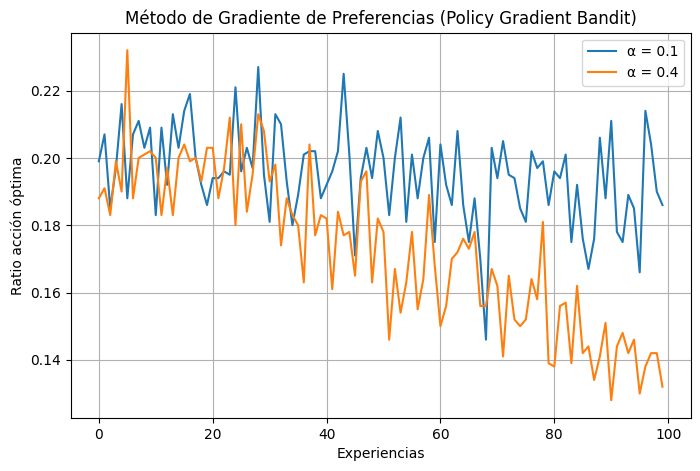

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 5
ACTIONS = {1: "up", 2: "down", 3: "left", 4: "right", 5: "stay"}

# Inicializa posiciones aleatorias de la serpiente y la comida
def init_positions():
    head = np.random.randint(0, GRID_SIZE, size=2)  # posición inicial de la serpiente
    food = np.random.randint(0, GRID_SIZE, size=2) # posición inicial de la comida
    while np.array_equal(head, food):
        food = np.random.randint(0, GRID_SIZE, size=2)
    return head, food

# Mueve la serpiente según la acción seleccionada
def move(head, action):
    if action == "up": # arriba
        head = head + np.array([-1, 0])  
    elif action == "down": 
        head = head + np.array([1, 0])
    elif action == "left":  # izquierda
        head = head + np.array([0, -1]) 
    elif action == "right": 
        head = head + np.array([0, 1])
    return head


# Calcula la recompensa del movimiento
def get_reward(head, food):
    if np.array_equal(head, food): 
        return 1
    elif np.any(head < 0) or np.any(head >= GRID_SIZE): 
        return -1
    else: 
        return 0

def softmax(x):
    exp_x = np.exp(x - np.max(x))  # para estabilidad numérica
    return exp_x / np.sum(exp_x)


partidas = 1000
turnos = 100
alphas = [0.1, 0.4]  # tasas de aprendizaje
recompensas_medias = np.zeros((len(alphas), turnos)) # Matriz para promediar recompensas
acciones_optimas = np.zeros((len(alphas), turnos))


for ej in range(partidas):
    for i, alpha in enumerate(alphas):
        H = np.zeros(5)                # preferencias iniciales
        pi = softmax(H)                # probabilidades iniciales
        recompensas = []               # historial de recompensas
        head, food = init_positions()
        mejor_accion = 1               # referencia (arbitraria)

        for exp in range(turnos):
            # --- Elegir acción según softmax ---
            a = np.random.choice(range(1, 6), p=pi)

            # --- Ejecutar acción ---
            new_head = move(head.copy(), ACTIONS[a])
            recompensa = get_reward(new_head, food)
            head = new_head
            recompensas.append(recompensa)

            # --- Recompensa media actual ---
            recompensa_media = np.mean(recompensas)

            # --- Actualizar preferencias (Gradiente de ascenso) ---
            for j in range(5):
                if j == (a - 1):
                    H[j] += alpha * (recompensa - recompensa_media) * (1 - pi[j])
                else:
                    H[j] -= alpha * (recompensa - recompensa_media) * pi[j]

            # --- Actualizar política ---
            pi = softmax(H)

            # --- Métricas ---
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

            # Reinicio si come o choca
            if recompensa != 0:
                head, food = init_positions()

recompensas_medias /= partidas
acciones_optimas /= partidas

plt.figure(figsize=(8,5))
for i, a in enumerate(alphas):
    plt.plot(acciones_optimas[i], label=f'α = {a}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Ratio acción óptima')
plt.title('Método de Gradiente de Preferencias (Policy Gradient Bandit)')
plt.show()
